# Week 3: Unsupervised Learning and Model Evaluation

This notebook covers:
- K-Means clustering
- Hierarchical clustering
- PCA for dimensionality reduction
- Model evaluation metrics
- Hyperparameter tuning

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

wine = load_wine()
X, y = wine.data, wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
print(df.head())
print('\nDataset shape:', df.shape)
print('\nTarget distribution:\n', df['target'].value_counts().sort_index())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

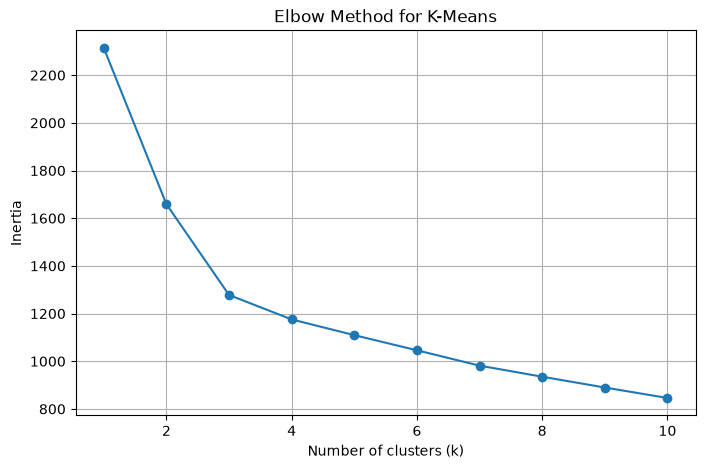

k=2 -> Silhouette Score: 0.2593
k=3 -> Silhouette Score: 0.2849
k=4 -> Silhouette Score: 0.2602
k=5 -> Silhouette Score: 0.2016
k=6 -> Silhouette Score: 0.2372


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'k={k} -> Silhouette Score: {score:.4f}')

In [4]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = cluster_labels
print(df[['target', 'KMeans_Cluster']].head())
print('\nCluster sizes:\n', df['KMeans_Cluster'].value_counts().sort_index())

   target  KMeans_Cluster
0       0               2
1       0               2
2       0               2
3       0               2
4       0               2

Cluster sizes:
 KMeans_Cluster
0    65
1    51
2    62
Name: count, dtype: int64


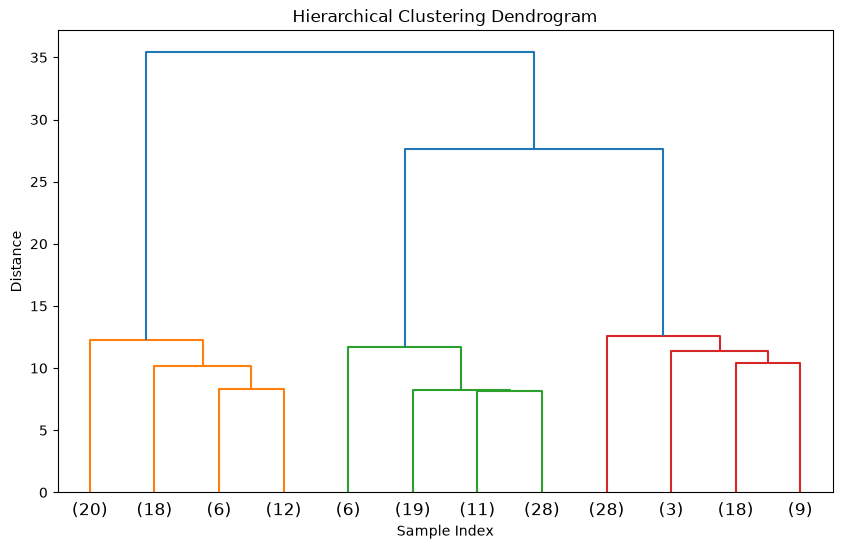

Hierarchical cluster sizes:
 Hierarchical_Cluster
0    58
1    56
2    64
Name: count, dtype: int64


In [5]:
mergings = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(mergings, truncate_mode='lastp', p=12, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hc_labels
print('Hierarchical cluster sizes:\n', df['Hierarchical_Cluster'].value_counts().sort_index())

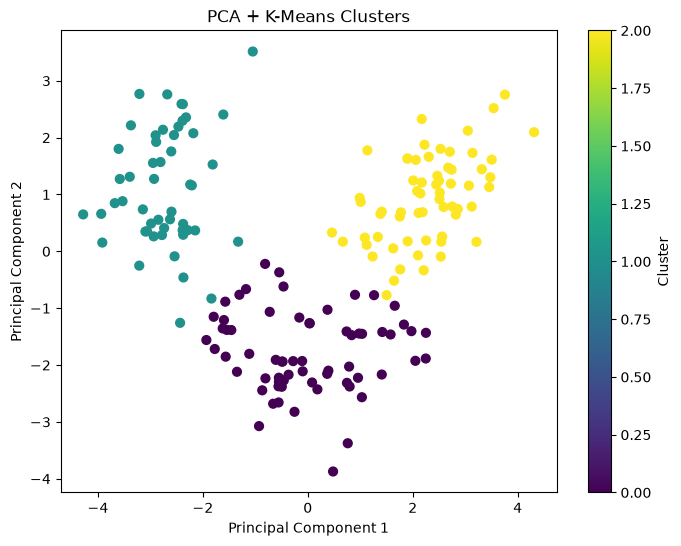

Explained variance ratio: [0.36198848 0.1920749 ]
Total explained variance: 0.5540633835693526


In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=40)
plt.title('PCA + K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, average='weighted', zero_division=0))
print('Recall:', recall_score(y_test, y_pred, average='weighted', zero_division=0))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted', zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

prob_pred = rf.predict_proba(X_test)
print('ROC-AUC (macro OVR):', roc_auc_score(y_test, prob_pred, multi_class='ovr', average='macro'))

cv_scores = cross_val_score(rf, X, y, cv=5)
print('Cross-validation scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean())

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
ROC-AUC (macro OVR): 1.0
Cross-validation scores: [0.97222222 0.94444444 0.97222222 0.97142857 1.        ]
Mean CV accuracy: 0.9720634920634922


In [9]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted')
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV F1 score:', grid_search.best_score_)

best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
print('Tuned model accuracy:', accuracy_score(y_test, best_pred))

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV F1 score: 0.9861338053740014
Tuned model accuracy: 1.0


## Conclusion

This notebook demonstrated both unsupervised learning and model evaluation. K-Means and Hierarchical Clustering were used to group wine samples into clusters, while PCA helped reduce the data into two dimensions for visualization.

For the evaluation part, we used a Random Forest classifier and measured accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC, and cross-validation performance. Hyperparameter tuning with GridSearchCV further improved the model selection process.

This gives a complete workflow for clustering analysis plus model evaluation and tuning in a single notebook.